In [3]:
# Seasonal Agriculture Performance Analysis

## Objective
To analyze agricultural performance across Kharif, Rabi and Zaid seasons,
identify seasonal patterns, relationships, significant differences and
provide evidence-based recommendations.

SyntaxError: invalid syntax (327390891.py, line 4)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from scipy.stats import kruskal, mannwhitneyu

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

In [7]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [8]:
df.shape

(4000, 28)

In [9]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [10]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [11]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [12]:
df.dtypes

Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Profit_INR      

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [14]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.00,3952.00,4000.00,4000.00,4000.00,4000.00,3960.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,3968.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,44714.17,526303.58,637860.05,111556.46,6045.57,5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,30266.16,294419.14,636974.71,545081.89,5572.94,8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,2594.00,26826.00,6107.00,-1019223.00,128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,21429.25,274577.50,207517.25,-148731.75,2268.75,1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,25913.00,519082.50,456830.50,3673.00,4435.00,2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,68279.00,761996.50,836874.75,216187.75,7829.75,5.15,54.90
max,15.00,1395.20,39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,1424.40,131240.00,1349990.00,5080900.00,4345421.00,40902.00,79.80,88.90


In [15]:
df.describe(include="object")

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


In [16]:
print("States:")
print(df["State"].unique())

print("\nDistricts:")
print(df["District"].unique())

print("\nCrops:")
print(df["Crop"].unique())

print("\nSeasons:")
print(df["Season"].unique())

print("\nIrrigation Methods:")
print(df["Irrigation_Method"].unique())

States:
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

Districts:
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crops:
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Seasons:
['Kharif' 'Rabi' 'Zaid']

Irrigation Methods:
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [17]:
df["Season"].value_counts()

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

In [18]:
df.isnull().sum()

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
numerical_columns = df.select_dtypes(include=np.number).columns

categorical_columns = df.select_dtypes(include="object").columns

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
Index(['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C',
       'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct',
       'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

Categorical columns:
Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method'], dtype='object')


In [21]:
df_clean = df.copy()

In [22]:
df_clean["Rainfall_mm"] = df_clean.groupby("Season")["Rainfall_mm"].transform(
    lambda x: x.fillna(x.median())
)

In [23]:
df_clean["Soil_Moisture_pct"] = df_clean.groupby("Season")["Soil_Moisture_pct"].transform(
    lambda x: x.fillna(x.median())
)

In [25]:
df_clean["Yield_Tonnes_Ha"] = df_clean.groupby(
    ["Season", "Crop"]
)["Yield_Tonnes_Ha"].transform(
    lambda x: x.fillna(x.median())
)

In [26]:
df_clean.isnull().sum()

Farm_ID                          0
State                            0
District                         0
Crop                             0
Season                           0
Farm_Area_Hectares               0
Rainfall_mm                      0
Avg_Temperature_C                0
Humidity_pct                     0
Sunlight_Hours_Day               0
Soil_pH                          0
Soil_Moisture_pct                0
Nitrogen_kg_ha                   0
Phosphorus_kg_ha                 0
Potassium_kg_ha                  0
Irrigation_Method                0
Fertilizer_kg_ha                 0
Pesticide_Litre_ha               0
Seed_Quality_Score               0
Yield_Tonnes_Ha                  0
Production_Tonnes                0
Market_Price_INR_Tonne           0
Total_Cost_INR                   0
Revenue_INR                      0
Profit_INR                       0
Water_Used_m3                    0
Water_Efficiency_t_per_1000m3    0
Disease_Pest_Risk_pct            0
dtype: int64

In [27]:
df_clean.duplicated().sum()

np.int64(0)

In [28]:
df_clean["Profit_Margin_pct"] = (
    df_clean["Profit_INR"] / df_clean["Revenue_INR"]
) * 100

In [29]:
df_clean["Revenue_per_ha"] = (
    df_clean["Revenue_INR"] / df_clean["Farm_Area_Hectares"]
)

In [30]:
df_clean["Cost_per_ha"] = (
    df_clean["Total_Cost_INR"] / df_clean["Farm_Area_Hectares"]
)

In [31]:
df_clean[[
    "Profit_INR",
    "Profit_Margin_pct",
    "Revenue_per_ha",
    "Cost_per_ha"
]].head()

,Profit_INR,Profit_Margin_pct,Revenue_per_ha,Cost_per_ha
0,-11852,-38.47,58132.08,80494.34
1,-451950,-1118.66,6186.98,75398.32
2,-124744,-65.49,39190.53,64858.02
3,-95704,-47.68,44608.89,65876.44
4,-144352,-74.56,45987.41,80275.30


In [36]:
df_clean = df.copy()
season_order = ["Kharif", "Rabi", "Zaid"]

In [37]:
environmental_summary = df_clean.groupby("Season").agg({
    "Rainfall_mm": "mean",
    "Avg_Temperature_C": "mean",
    "Humidity_pct": "mean",
    "Sunlight_Hours_Day": "mean",
    "Soil_Moisture_pct": "mean"
}).reindex(season_order)

environmental_summary

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,852.08,28.45,71.81,6.79,31.20
Rabi,436.00,23.49,57.89,7.59,24.05
Zaid,299.42,31.04,52.01,8.18,19.17


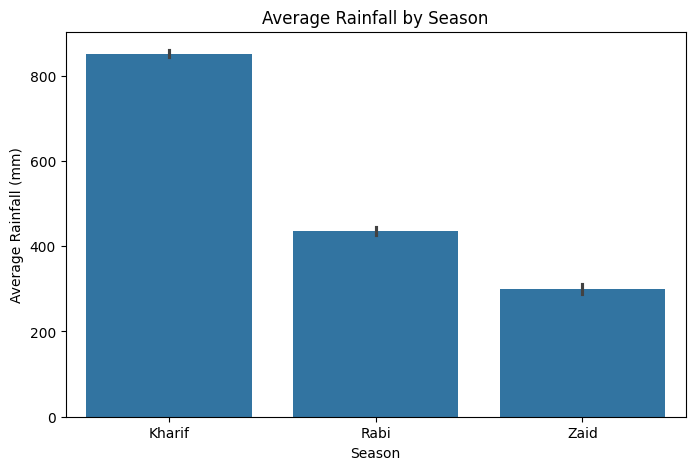

In [38]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_clean,
    x="Season",
    y="Rainfall_mm",
    order=season_order,
    estimator="mean"
)

plt.title("Average Rainfall by Season")
plt.xlabel("Season")
plt.ylabel("Average Rainfall (mm)")
plt.show()

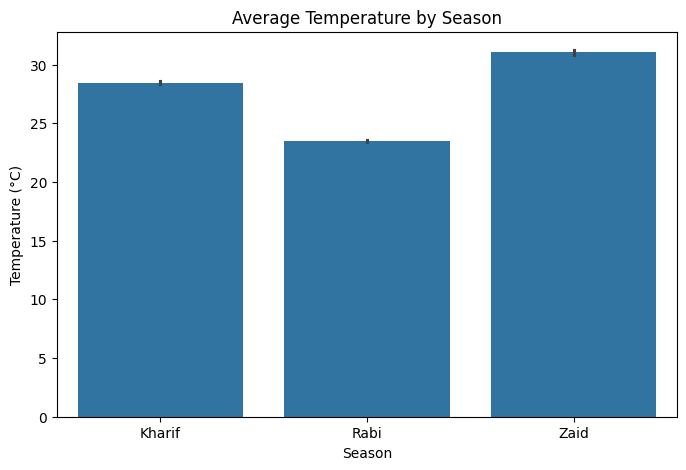

In [39]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_clean,
    x="Season",
    y="Avg_Temperature_C",
    order=season_order,
    estimator="mean"
)

plt.title("Average Temperature by Season")
plt.xlabel("Season")
plt.ylabel("Temperature (°C)")
plt.show()

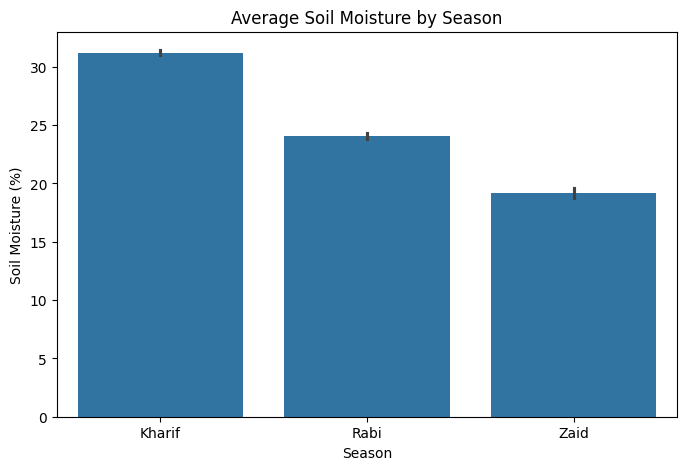

In [40]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_clean,
    x="Season",
    y="Soil_Moisture_pct",
    order=season_order,
    estimator="mean"
)

plt.title("Average Soil Moisture by Season")
plt.xlabel("Season")
plt.ylabel("Soil Moisture (%)")
plt.show()

In [41]:
season_performance = df_clean.groupby("Season").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Revenue_INR": "mean",
    "Total_Cost_INR": "mean",
    "Profit_INR": "mean",
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean",
    "Disease_Pest_Risk_pct": "mean"
}).reindex(season_order)

season_performance

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,
Kharif,5.64,46.31,710719.06,531804.41,178914.65,6102.20,5.89,54.47
Rabi,5.08,41.49,601526.05,513836.58,87689.47,5846.99,5.19,40.48
Zaid,4.67,38.89,519171.90,543976.73,-24804.82,6419.89,4.41,38.22


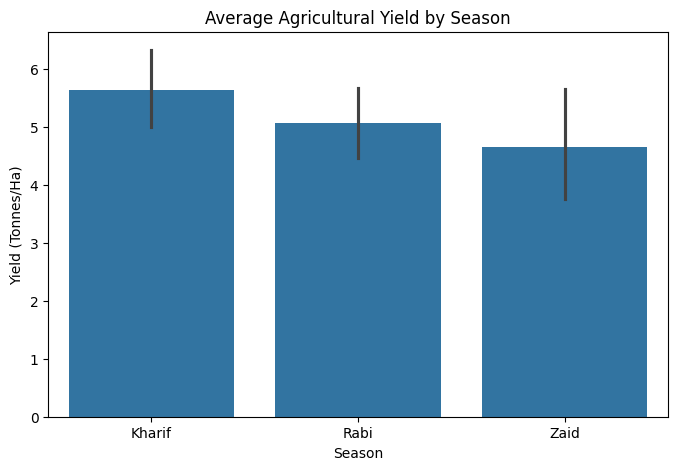

In [42]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_clean,
    x="Season",
    y="Yield_Tonnes_Ha",
    order=season_order,
    estimator="mean"
)

plt.title("Average Agricultural Yield by Season")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

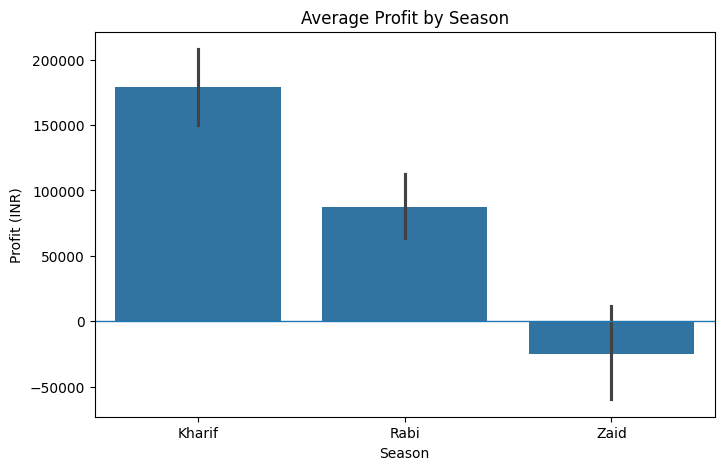

In [43]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_clean,
    x="Season",
    y="Profit_INR",
    order=season_order,
    estimator="mean"
)

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.axhline(0, linewidth=1)
plt.show()

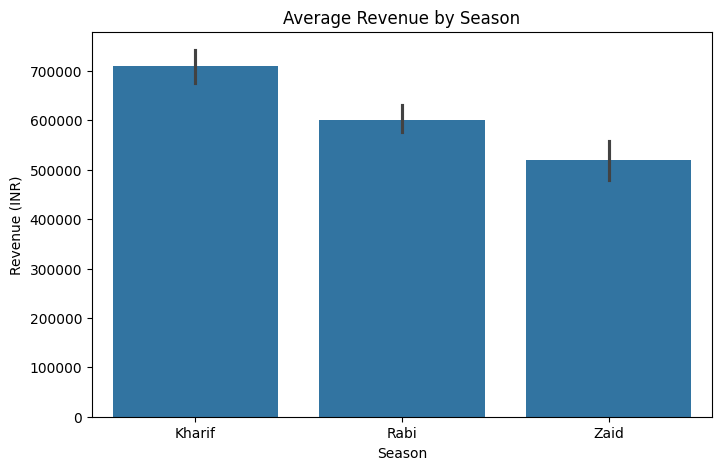

In [44]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_clean,
    x="Season",
    y="Revenue_INR",
    order=season_order,
    estimator="mean"
)

plt.title("Average Revenue by Season")
plt.xlabel("Season")
plt.ylabel("Revenue (INR)")
plt.show()

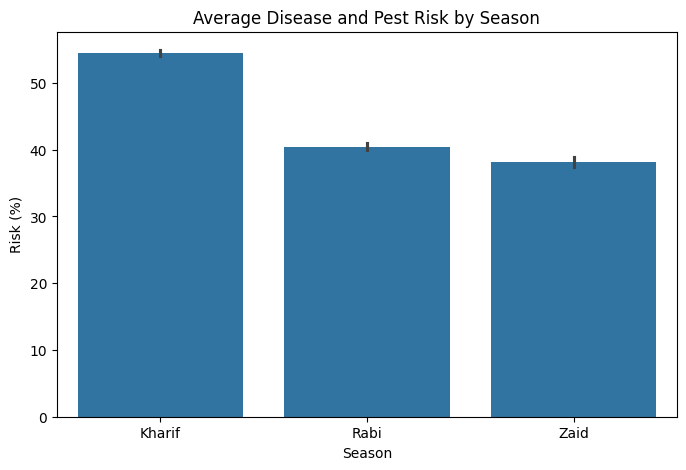

In [45]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_clean,
    x="Season",
    y="Disease_Pest_Risk_pct",
    order=season_order,
    estimator="mean"
)

plt.title("Average Disease and Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Risk (%)")
plt.show()

In [47]:
season_order = ["Kharif", "Rabi", "Zaid"]

In [48]:
crop_season_yield = pd.pivot_table(
    df_clean,
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
).reindex(columns=season_order)

crop_season_yield

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.95
Groundnut,1.48,1.22,1.04
Maize,2.97,2.61,2.30
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,53.46,43.94,38.42
Wheat,2.26,2.06,1.75


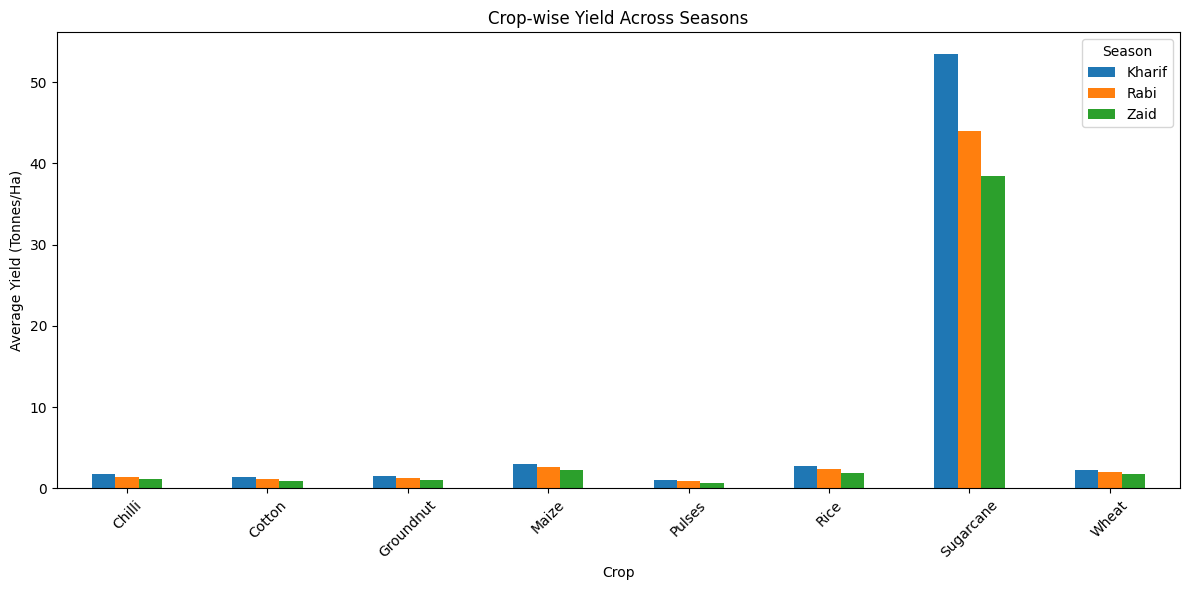

In [49]:
crop_season_yield.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Crop-wise Yield Across Seasons")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.legend(title="Season")
plt.tight_layout()
plt.show()

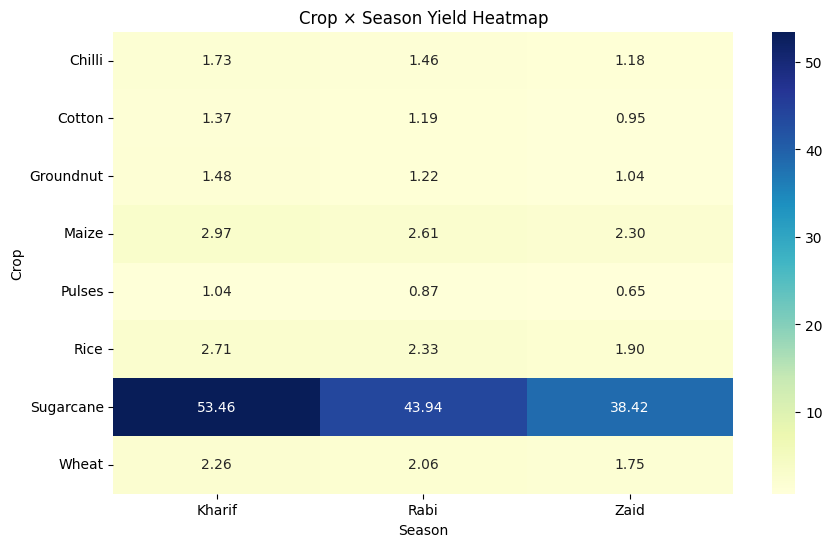

In [50]:
plt.figure(figsize=(10,6))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Crop × Season Yield Heatmap")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.show()

In [51]:
irrigation_yield = pd.pivot_table(
    df_clean,
    values="Yield_Tonnes_Ha",
    index="Season",
    columns="Irrigation_Method",
    aggfunc="mean"
)

irrigation_yield

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,7.26,5.00,5.72,4.67
Rabi,6.21,5.10,3.94,5.36
Zaid,5.85,4.03,3.06,6.17


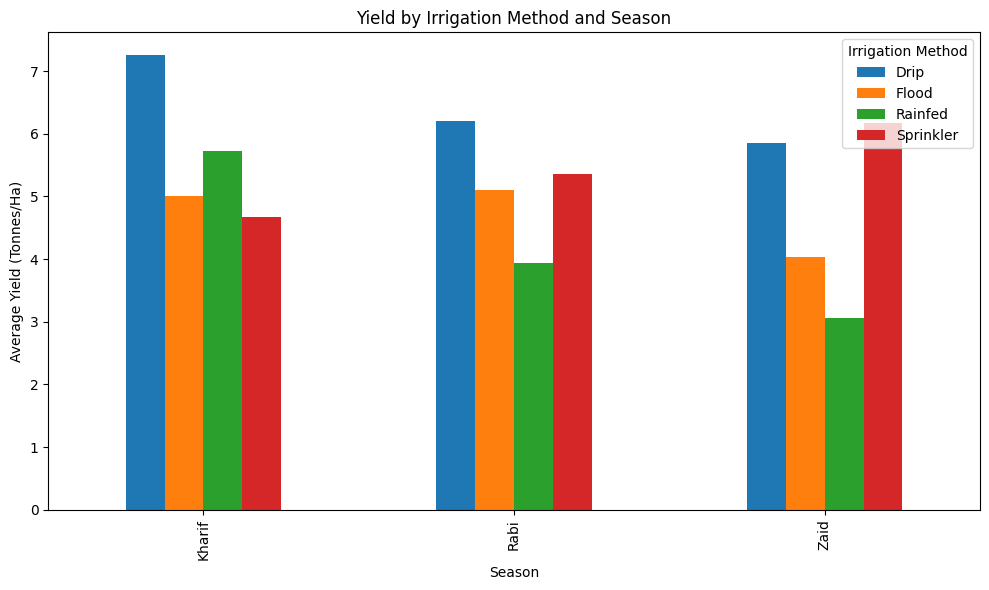

In [52]:
irrigation_yield.reindex(season_order).plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Yield by Irrigation Method and Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.legend(title="Irrigation Method")
plt.tight_layout()
plt.show()

In [53]:
resource_summary = df_clean.groupby("Season").agg({
    "Water_Used_m3": "mean",
    "Fertilizer_kg_ha": "mean",
    "Pesticide_Litre_ha": "mean",
    "Nitrogen_kg_ha": "mean",
    "Phosphorus_kg_ha": "mean",
    "Potassium_kg_ha": "mean"
}).reindex(season_order)

resource_summary

,Water_Used_m3,Fertilizer_kg_ha,Pesticide_Litre_ha,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha
Season,,,,,,
Kharif,6102.20,187.08,5.08,120.02,58.10,105.30
Rabi,5846.99,185.41,5.02,120.40,57.31,103.93
Zaid,6419.89,184.64,5.17,120.53,58.13,105.42


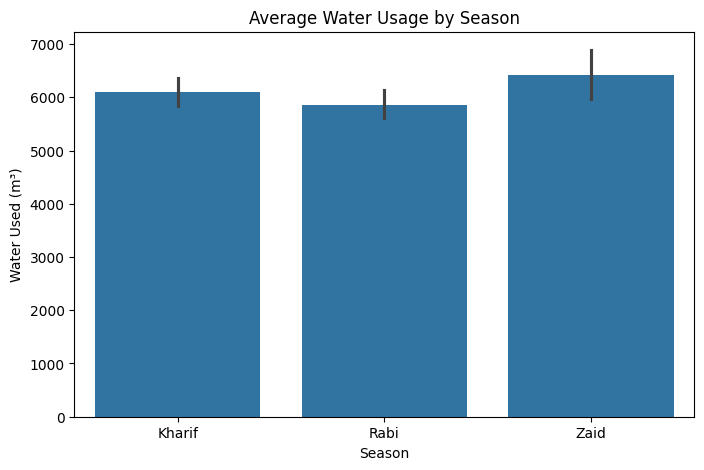

In [54]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_clean,
    x="Season",
    y="Water_Used_m3",
    order=season_order,
    estimator="mean"
)

plt.title("Average Water Usage by Season")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")
plt.show()

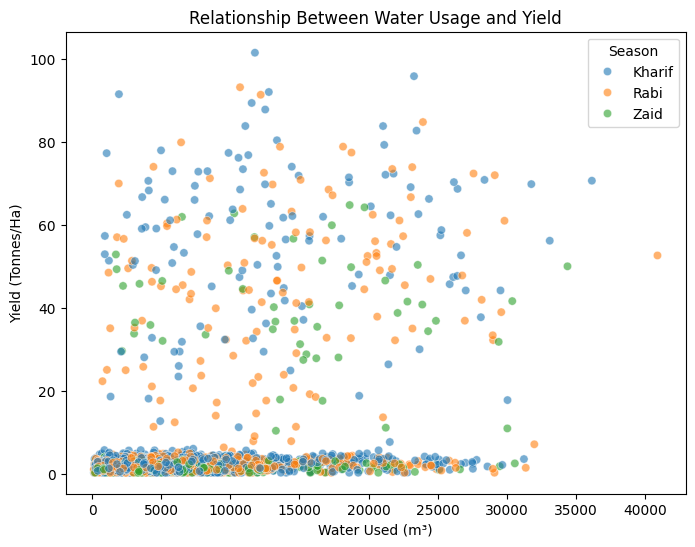

In [55]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_clean,
    x="Water_Used_m3",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.6
)

plt.title("Relationship Between Water Usage and Yield")
plt.xlabel("Water Used (m³)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

In [56]:
correlation_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Water_Used_m3",
    "Disease_Pest_Risk_pct",
    "Yield_Tonnes_Ha",
    "Profit_INR"
]

correlation_matrix = df_clean[correlation_columns].corr()

correlation_matrix

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Disease_Pest_Risk_pct,Yield_Tonnes_Ha,Profit_INR
Rainfall_mm,1.00,0.20,0.52,0.52,0.01,0.02,0.03,0.02,0.00,0.00,0.63,0.03,0.11
Avg_Temperature_C,0.20,1.00,0.14,0.08,0.02,0.01,0.02,0.02,0.01,0.02,0.25,0.01,0.01
Humidity_pct,0.52,0.14,1.00,0.45,0.00,-0.01,-0.00,0.02,-0.00,-0.00,0.55,0.01,0.06
Soil_Moisture_pct,0.52,0.08,0.45,1.00,0.01,0.01,0.01,0.01,-0.02,0.00,0.38,0.01,0.09
Nitrogen_kg_ha,0.01,0.02,0.00,0.01,1.00,0.01,0.01,-0.03,0.01,0.02,-0.01,0.05,0.09
Phosphorus_kg_ha,0.02,0.01,-0.01,0.01,0.01,1.00,0.00,0.01,-0.03,-0.00,0.03,0.05,0.05
Potassium_kg_ha,0.03,0.02,-0.00,0.01,0.01,0.00,1.00,0.02,-0.00,0.00,0.01,0.00,0.03
Fertilizer_kg_ha,0.02,0.02,0.02,0.01,-0.03,0.01,0.02,1.00,-0.00,0.00,0.02,0.00,-0.07
Pesticide_Litre_ha,0.00,0.01,-0.00,-0.02,0.01,-0.03,-0.00,-0.00,1.00,0.00,-0.47,-0.01,-0.03
Water_Used_m3,0.00,0.02,-0.00,0.00,0.02,-0.00,0.00,0.00,0.00,1.00,0.01,0.39,0.19


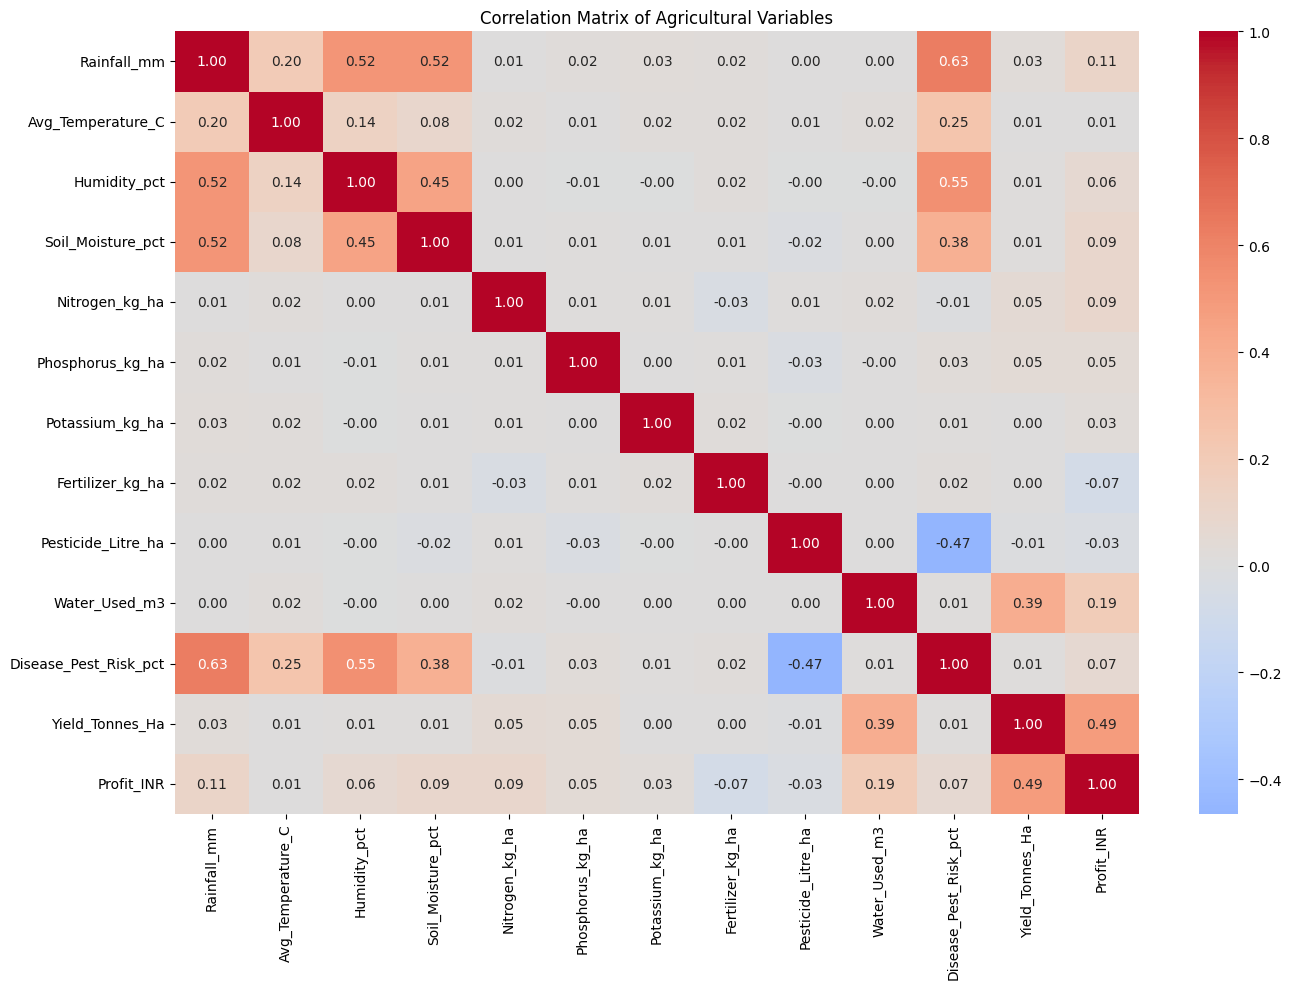

In [57]:
plt.figure(figsize=(14,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Agricultural Variables")
plt.tight_layout()
plt.show()

In [58]:
yield_correlation = correlation_matrix["Yield_Tonnes_Ha"].sort_values(
    ascending=False
)

yield_correlation

Yield_Tonnes_Ha          1.00
Profit_INR               0.49
Water_Used_m3            0.39
Nitrogen_kg_ha           0.05
Phosphorus_kg_ha         0.05
Rainfall_mm              0.03
Disease_Pest_Risk_pct    0.01
Humidity_pct             0.01
Soil_Moisture_pct        0.01
Avg_Temperature_C        0.01
Potassium_kg_ha          0.00
Fertilizer_kg_ha         0.00
Pesticide_Litre_ha      -0.01
Name: Yield_Tonnes_Ha, dtype: float64

In [59]:
profit_correlation = correlation_matrix["Profit_INR"].sort_values(
    ascending=False
)

profit_correlation

Profit_INR               1.00
Yield_Tonnes_Ha          0.49
Water_Used_m3            0.19
Rainfall_mm              0.11
Soil_Moisture_pct        0.09
Nitrogen_kg_ha           0.09
Disease_Pest_Risk_pct    0.07
Humidity_pct             0.06
Phosphorus_kg_ha         0.05
Potassium_kg_ha          0.03
Avg_Temperature_C        0.01
Pesticide_Litre_ha      -0.03
Fertilizer_kg_ha        -0.07
Name: Profit_INR, dtype: float64

In [60]:
kharif_yield = df_clean[
    df_clean["Season"] == "Kharif"
]["Yield_Tonnes_Ha"]

rabi_yield = df_clean[
    df_clean["Season"] == "Rabi"
]["Yield_Tonnes_Ha"]

zaid_yield = df_clean[
    df_clean["Season"] == "Zaid"
]["Yield_Tonnes_Ha"]

kruskal_result = kruskal(
    kharif_yield,
    rabi_yield,
    zaid_yield
)

kruskal_result

KruskalResult(statistic=np.float64(nan), pvalue=np.float64(nan))

In [61]:
if kruskal_result.pvalue < 0.05:
    print("There is a statistically significant difference in yield between seasons.")
else:
    print("There is no statistically significant difference in yield between seasons.")

There is no statistically significant difference in yield between seasons.


In [62]:
pairs = [
    ("Kharif", "Rabi"),
    ("Kharif", "Zaid"),
    ("Rabi", "Zaid")
]

for season1, season2 in pairs:

    group1 = df_clean[
        df_clean["Season"] == season1
    ]["Yield_Tonnes_Ha"]

    group2 = df_clean[
        df_clean["Season"] == season2
    ]["Yield_Tonnes_Ha"]

    result = mannwhitneyu(
        group1,
        group2,
        alternative="two-sided"
    )

    print(
        season1,
        "vs",
        season2,
        "p-value:",
        result.pvalue
    )

Kharif vs Rabi p-value: nan
Kharif vs Zaid p-value: nan
Rabi vs Zaid p-value: nan


In [63]:
kharif_profit = df_clean[
    df_clean["Season"] == "Kharif"
]["Profit_INR"]

rabi_profit = df_clean[
    df_clean["Season"] == "Rabi"
]["Profit_INR"]

zaid_profit = df_clean[
    df_clean["Season"] == "Zaid"
]["Profit_INR"]

profit_test = kruskal(
    kharif_profit,
    rabi_profit,
    zaid_profit
)

profit_test

KruskalResult(statistic=np.float64(101.92605491126021), pvalue=np.float64(7.362721866797111e-23))

In [64]:
kharif_risk = df_clean[
    df_clean["Season"] == "Kharif"
]["Disease_Pest_Risk_pct"]

rabi_risk = df_clean[
    df_clean["Season"] == "Rabi"
]["Disease_Pest_Risk_pct"]

zaid_risk = df_clean[
    df_clean["Season"] == "Zaid"
]["Disease_Pest_Risk_pct"]

risk_test = kruskal(
    kharif_risk,
    rabi_risk,
    zaid_risk
)

risk_test

KruskalResult(statistic=np.float64(1430.9101341246858), pvalue=np.float64(1.913428882117e-311))

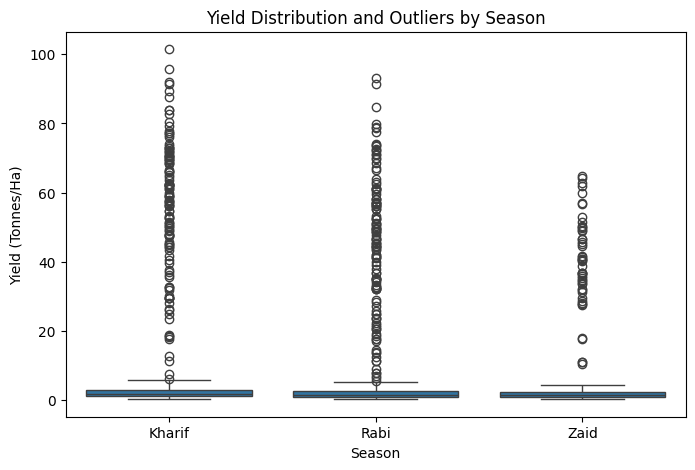

In [65]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="Season",
    y="Yield_Tonnes_Ha",
    order=season_order
)

plt.title("Yield Distribution and Outliers by Season")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

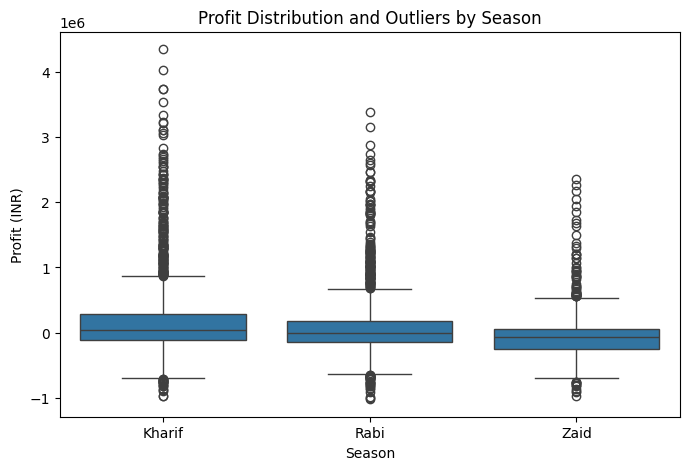

In [66]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="Season",
    y="Profit_INR",
    order=season_order
)

plt.title("Profit Distribution and Outliers by Season")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.show()

In [67]:
df_clean.nlargest(
    10,
    "Profit_INR"
)[[
    "Farm_ID",
    "State",
    "District",
    "Crop",
    "Season",
    "Yield_Tonnes_Ha",
    "Revenue_INR",
    "Profit_INR"
]]

,Farm_ID,State,District,Crop,Season,Yield_Tonnes_Ha,Revenue_INR,Profit_INR
2236,SF12237,Punjab,Rajkot,Chilli,Kharif,3.90,5057448,4345421
626,SF10627,Maharashtra,Warangal,Chilli,Kharif,2.92,5080900,4021850
3425,SF13426,Madhya Pradesh,Rajkot,Sugarcane,Kharif,82.68,4485260,3740099
1690,SF11691,Karnataka,Warangal,Chilli,Kharif,3.01,4522464,3738329
247,SF10248,Maharashtra,Krishna,Chilli,Kharif,3.09,4825365,3542204
357,SF10358,Punjab,Warangal,Sugarcane,Rabi,84.75,4350998,3378879
3423,SF13424,Andhra Pradesh,Indore,Sugarcane,Kharif,95.79,4428460,3330582
1930,SF11931,Tamil Nadu,Guntur,Sugarcane,Kharif,79.25,4108301,3232970
3983,SF13984,Gujarat,Nashik,Chilli,Kharif,3.02,4055609,3211345
263,SF10264,Maharashtra,Ludhiana,Chilli,Rabi,2.53,3987664,3159447


In [68]:
df_clean.nsmallest(
    10,
    "Profit_INR"
)[[
    "Farm_ID",
    "State",
    "District",
    "Crop",
    "Season",
    "Yield_Tonnes_Ha",
    "Revenue_INR",
    "Profit_INR"
]]

,Farm_ID,State,District,Crop,Season,Yield_Tonnes_Ha,Revenue_INR,Profit_INR
780,SF10781,Andhra Pradesh,Ludhiana,Groundnut,Rabi,0.30,280139,-1019223
2210,SF12211,Andhra Pradesh,Raichur,Wheat,Rabi,0.30,102497,-995195
3625,SF13626,Punjab,Krishna,Maize,Rabi,0.97,226503,-981050
2182,SF12183,Andhra Pradesh,Krishna,Rice,Kharif,1.01,320865,-976860
104,SF10105,Gujarat,Krishna,Wheat,Zaid,0.30,98792,-965197
3394,SF13395,Gujarat,Erode,Wheat,Kharif,0.30,99644,-963396
2730,SF12731,Madhya Pradesh,Ludhiana,Rice,Rabi,NaN,89197,-906082
1311,SF11312,Punjab,Rajkot,Rice,Zaid,0.45,163084,-902740
585,SF10586,Telangana,Warangal,Cotton,Zaid,0.30,198300,-895730
3090,SF13091,Karnataka,Ludhiana,Maize,Kharif,0.41,109026,-890641


In [69]:
crop_performance = df_clean.groupby("Crop").agg({
    "Yield_Tonnes_Ha": "mean",
    "Revenue_INR": "mean",
    "Profit_INR": "mean"
}).sort_values(
    "Profit_INR",
    ascending=False
)

crop_performance

,Yield_Tonnes_Ha,Revenue_INR,Profit_INR
Crop,,,
Sugarcane,46.94,1371980.11,817187.99
Chilli,1.54,1276777.23,750878.34
Cotton,1.23,639423.08,124546.92
Groundnut,1.32,542935.50,44858.12
Pulses,0.92,528465.87,-4238.05
Maize,2.72,457067.99,-83978.33
Rice,2.44,423615.26,-102213.50
Wheat,2.11,400104.89,-123398.34


In [70]:
df_clean.groupby(
    ["Season", "Crop"]
)["Profit_INR"].mean().round(2)

Season  Crop     
Kharif  Chilli       954380.42
        Cotton       216999.55
        Groundnut    108265.44
        Maize        -39332.67
        Pulses        43338.90
        Rice         -64903.40
        Sugarcane   1000790.81
        Wheat       -105871.87
Rabi    Chilli       638572.50
        Cotton       107343.59
        Groundnut     10416.54
        Maize        -89133.40
        Pulses       -14309.14
        Rice         -98427.87
        Sugarcane    731612.86
        Wheat       -119954.57
Zaid    Chilli       448659.09
        Cotton       -53925.34
        Groundnut    -68872.50
        Maize       -194049.17
        Pulses      -139227.81
        Rice        -227239.34
        Sugarcane    583635.80
        Wheat       -193208.95
Name: Profit_INR, dtype: float64

In [72]:
profitable_percentage = (
    df_clean.groupby("Season")["Profit_INR"]
    .apply(lambda x: (x > 0).mean() * 100)
    .reindex(season_order)
)

profitable_percentage

Season
Kharif   57.79
Rabi     48.86
Zaid     35.52
Name: Profit_INR, dtype: float64

In [73]:
state_season_yield = pd.pivot_table(
    df_clean,
    values="Yield_Tonnes_Ha",
    index="State",
    columns="Season",
    aggfunc="mean"
)

state_season_yield

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.69,3.49,4.48
Gujarat,6.34,5.52,4.10
Karnataka,6.52,4.61,6.62
Madhya Pradesh,6.00,3.80,5.54
Maharashtra,5.45,5.50,2.29
Punjab,4.10,8.61,5.91
Tamil Nadu,5.52,4.56,4.10
Telangana,5.57,4.83,4.28


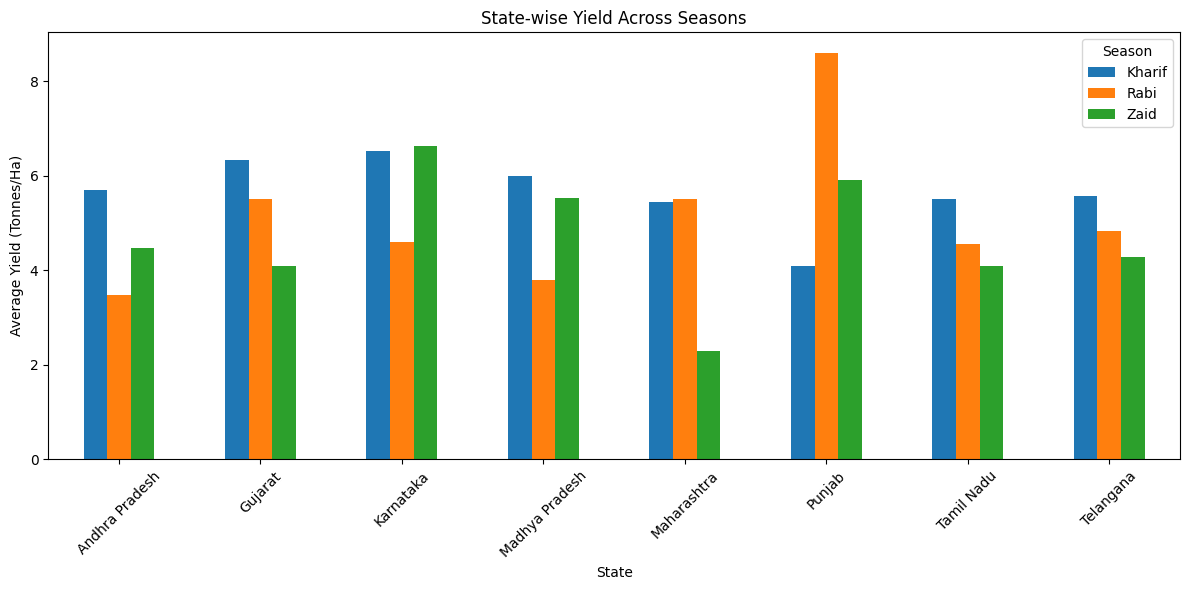

In [74]:
state_season_yield.reindex(columns=season_order).plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("State-wise Yield Across Seasons")
plt.xlabel("State")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.legend(title="Season")
plt.tight_layout()
plt.show()

In [75]:
district_season_yield = pd.pivot_table(
    df_clean,
    values="Yield_Tonnes_Ha",
    index="District",
    columns="Season",
    aggfunc="mean"
)

district_season_yield

Season,Kharif,Rabi,Zaid
District,,,
Erode,4.33,4.48,3.31
Guntur,6.02,4.58,6.30
Indore,6.12,3.54,4.54
Krishna,5.51,4.76,2.91
Ludhiana,6.41,5.62,5.08
Nalgonda,6.58,4.47,7.51
Nashik,5.55,4.72,3.39
Raichur,4.12,6.74,3.29
Rajkot,6.69,5.96,4.33


In [76]:
df_clean.to_csv(
    "seasonal_agriculture_performance_cleaned.csv",
    index=False
)

In [77]:
final_summary = df_clean.groupby("Season").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Rainfall=("Rainfall_mm", "mean"),
    Average_Temperature=("Avg_Temperature_C", "mean"),
    Average_Soil_Moisture=("Soil_Moisture_pct", "mean"),
    Average_Water_Use=("Water_Used_m3", "mean"),
    Average_Disease_Risk=("Disease_Pest_Risk_pct", "mean")
).reindex(season_order)

final_summary.round(2)

,Average_Yield,Average_Revenue,Average_Profit,Average_Rainfall,Average_Temperature,Average_Soil_Moisture,Average_Water_Use,Average_Disease_Risk
Season,,,,,,,,
Kharif,5.64,710719.06,178914.65,852.08,28.45,31.20,6102.20,54.47
Rabi,5.08,601526.05,87689.47,436.00,23.49,24.05,5846.99,40.48
Zaid,4.67,519171.90,-24804.82,299.42,31.04,19.17,6419.89,38.22


In [ ]:
# Conclusions

Based on the analysis:

1. Agricultural performance varies considerably across Kharif, Rabi and Zaid seasons.

2. Kharif records the highest average agricultural yield and the strongest
average economic performance in the dataset.

3. Zaid shows comparatively weaker average profitability, indicating that
seasonal resource and environmental conditions may create additional
economic challenges.

4. Rainfall, temperature and soil moisture show clear differences between
seasons.

5. Crop performance is not uniform across seasons. Some crops perform
considerably better than others under particular seasonal conditions.

6. Resource usage, particularly water usage and fertilizer application,
varies across seasons.

7. Statistical testing can be used to determine whether the observed
differences in yield and other outcomes are statistically significant.

8. Correlation analysis reveals relationships between environmental/resource
variables and agricultural outcomes; however, correlation does not imply
causation.

9. Outlier analysis reveals farms with unusually high yields, high profits
or substantial losses that require further investigation.

10. The findings can support seasonal crop planning, resource allocation,
irrigation planning and risk management.

In [ ]:
# Recommendations

1. Prioritize crop-season combinations that demonstrate consistently strong
yield and profitability.

2. Improve irrigation planning during seasons with lower rainfall and soil
moisture.

3. Strengthen disease and pest monitoring during seasons with higher
observed risk.

4. Investigate farms showing unusually high losses to identify issues related
to production cost, yield, market price or resource utilization.

5. Promote efficient use of water and agricultural inputs rather than
maximizing resource consumption.

6. Use seasonal historical data to support evidence-based crop planning.

7. Future analysis should incorporate multiple years of data and additional
weather/market information to improve forecasting and decision-making.

In [ ]:
Rajiv Gandhi Institute of Technology